# Analyzing Requested Feature Values
1. Error Bar plots for each requested parameter in Venus
2. Examine set ## with large ranges / outlier values
3. Map outliers in accumulated data to raw measurements (watch_data)

Also examine other non-requested features for values / ranges

### Imports

In [43]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [44]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from venus_ml import VenusDataset

### Requested Features and Expected Values

In [45]:
requested = {
    'k18_fw_mean': [1.4e3, 'Watts'],
    'g28_fw_mean': [4.3e3, 'Watts'],
    'inj_i_mean': [185, 'Amps'],
    'ext_i_mean': [137, 'Amps'],
    'mid_i_mean': [153, 'Amps'],
    'sext_i_mean': [430, 'Amps'],
    'extraction_v_mean': [20, 'kV'],
    'puller_v_mean': [2, 'kV'],
}

non_requested = [
    'inj_mbar_mean',
    'k18_ref_mean',
    'x_ray_source_mean',
    'x_ray_exit_mean',
    'bias_i_mean',
    'extraction_i_mean',
]

### Get Full Dataset w/Features

In [46]:
features = ['run_id', 'unix_time', 'fcv1_i_mean'] + list(requested.keys()) + non_requested
print(features)
data_set_config = {
    "file_path": "../data/watch_data.parquet",
    "input_columns": features,
    "output_columns": [],

}
dataset = VenusDataset(**data_set_config)
(dataset.inputs.head())

['run_id', 'unix_time', 'fcv1_i_mean', 'k18_fw_mean', 'g28_fw_mean', 'inj_i_mean', 'ext_i_mean', 'mid_i_mean', 'sext_i_mean', 'extraction_v_mean', 'puller_v_mean', 'inj_mbar_mean', 'k18_ref_mean', 'x_ray_source_mean', 'x_ray_exit_mean', 'bias_i_mean', 'extraction_i_mean']


,unix_time,fcv1_i_mean,inj_i_mean,ext_i_mean,mid_i_mean,sext_i_mean,inj_mbar_mean,bias_i_mean,k18_fw_mean,k18_ref_mean,g28_fw_mean,x_ray_source_mean,x_ray_exit_mean,extraction_v_mean,extraction_i_mean,puller_v_mean,run_id
0,1.662169e+09,0.000275,185.000067,137.012533,152.987850,429.999233,1.131366e-07,3.184975,1421.000000,25.000000,4300.416667,207.180000,6.706667,19.990632,4.373885,2.008709,00
1,1.662169e+09,0.000191,185.000400,137.013000,152.988300,429.999033,1.146935e-07,-0.110007,1411.966667,26.716667,4304.850000,157.726667,5.600000,19.990843,3.289810,2.008701,00
2,1.662169e+09,0.000513,185.000000,137.012600,152.988200,429.999850,9.998214e-08,4.540507,1410.500000,25.966667,4299.683333,170.406667,6.020000,19.990833,4.541913,2.008607,00
3,1.662169e+09,0.000271,185.000467,137.012600,152.988033,429.998917,1.112093e-07,3.022831,1416.966667,24.866667,4299.933333,209.053333,6.800000,19.990768,4.374948,2.008685,00
4,1.662170e+09,0.000273,185.000917,137.012133,152.987967,429.999300,1.106831e-07,2.942545,1418.533333,24.683333,4298.533333,207.866667,6.613333,19.990838,4.363171,2.008732,00


In [47]:
feat = 'mid_i_mean'
dataset.inputs[feat].mean(), dataset.inputs[feat].min(), dataset.inputs[feat].max(), dataset.inputs[feat].std()

(152.98814483100037,
 152.98426666666666,
 152.99474999999998,
 0.0003014512561194685)

### Helpers 

In [48]:
# Get feature split by run
def split_by_set(dataset, feature):
    grouped_data = dataset.inputs.groupby('run_id')[feature].apply(lambda x: np.array(x)).to_dict()
    return grouped_data

# get set_names, EV, mean, [lower error, upper error]
def get_plot_data(grouped_data, feature, expected=True):
    set_names = list(grouped_data.keys())
    means = [np.array(values).mean() for values in grouped_data.values()]
    # stds = [values.std() for values in grouped_data.values()]
    mins = [values.min() for values in grouped_data.values()]
    maxs = [values.max() for values in grouped_data.values()]
    
    lower_errors = np.subtract(means, mins)
    upper_errors = np.subtract(maxs, means)
    errors = [lower_errors, upper_errors]
    if expected:
        expected = requested[feature][0]
        return set_names, expected, means, errors
    return set_names, means, errors

def feature_error_plot(dataset, feature):
    unit = requested[feature][1]
    grouped_data = split_by_set(dataset, feature)
    set_names, expected, means, errors = get_plot_data(grouped_data, feature)
    
    plt.figure(figsize=(10, 5))
    # plt.style.use('fivethirtyeight')
    plt.errorbar(x=set_names, y=means, yerr=errors, fmt='o', ecolor='grey', capsize=8, label='Mean Value')
    plt.axhline(y=expected, color='r', linestyle='--', label=f'Expected: {expected} {unit}')
    plt.title(f'Error Bar Plot of {feature} Across Runs')
    plt.xlabel('Set ##')
    plt.ylabel(f"{feature} ({unit})")
    plt.xticks(set_names, labels=grouped_data.keys()) 
    plt.legend(loc='upper right')
    plt.tight_layout() 
    plt.margins(y=0.3)
    # plt.grid(True)
    plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
    plt.show()

def non_requested_error_plot(dataset, feature):
    grouped_data = split_by_set(dataset, feature)
    set_names, means, errors = get_plot_data(grouped_data, feature, expected=False)
    
    plt.figure(figsize=(10, 5))
    plt.errorbar(x=set_names, y=means, yerr=errors, fmt='o', ecolor='grey', capsize=8, label='Mean Value')
    plt.title(f'Error Bar Plot of {feature} Across Runs')
    plt.xlabel('Set ##')
    plt.ylabel(feature)
    plt.xticks(set_names, labels=grouped_data.keys())
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.margins(y=0.3)
    plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
    plt.show()

def feature_error_plot_w_std(dataset, feature):
    unit = requested[feature][1]
    grouped_data = split_by_set(dataset, feature)
    set_names, expected, means, errors = get_plot_data(grouped_data, feature)
    
    # Calculate overall mean and standard deviation for the feature across all data
    overall_mean = dataset.inputs[feature].mean()
    std_dev = dataset.inputs[feature].std()
    one_std_above = overall_mean + 2 * std_dev
    one_std_below = overall_mean - 2* std_dev
    
    plt.figure(figsize=(10, 5))
    plt.errorbar(x=set_names, y=means, yerr=errors, fmt='o', ecolor='grey', capsize=8, label='Mean Value')
    plt.axhline(y=expected, color='r', linestyle='--', label=f'Expected: {expected} {unit}')
    plt.axhline(y=one_std_above, color='blue', linestyle=':', label='2 Std Dev Above')
    plt.axhline(y=one_std_below, color='blue', linestyle=':', label='2 Std Dev Below')
    plt.title(f'Error Bar Plot of {feature} Across Runs')
    plt.xlabel('Set ##')
    plt.ylabel(f"{feature} ({unit})")
    plt.xticks(set_names, labels=grouped_data.keys())
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.margins(y=0.3)
    plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
    plt.show()


[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


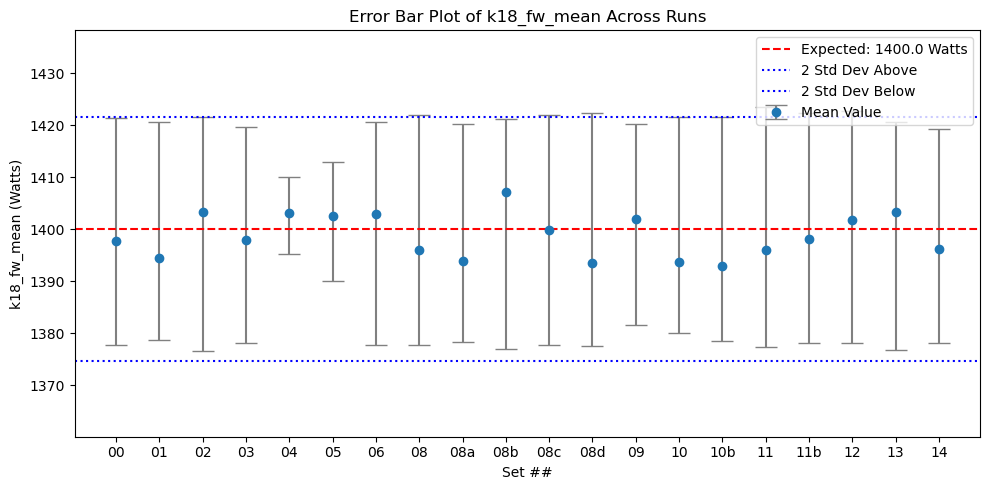

In [49]:
feature_error_plot_w_std(dataset, 'k18_fw_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


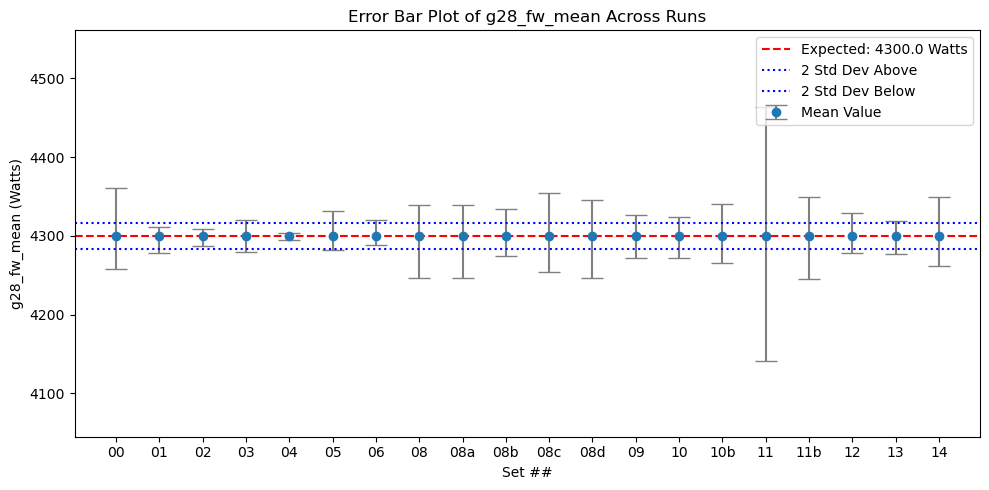

In [50]:
feature_error_plot_w_std(dataset, 'g28_fw_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


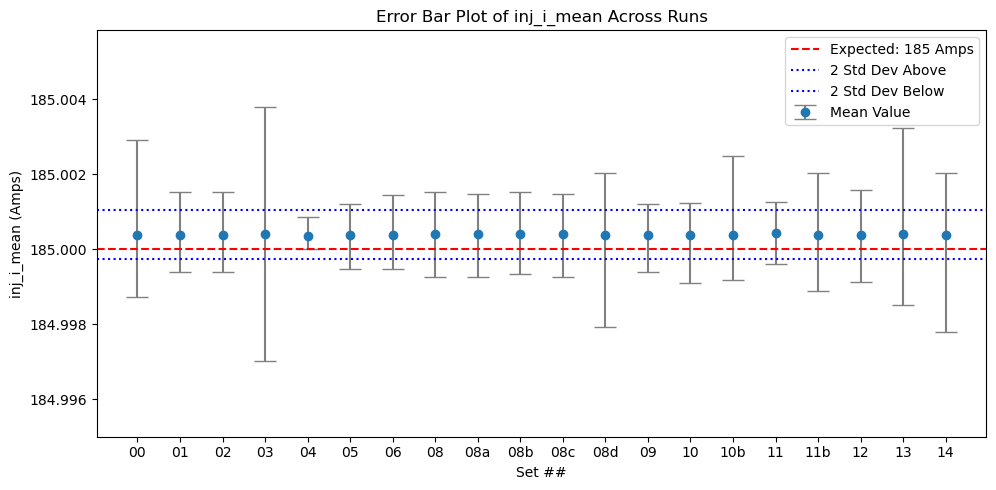

In [51]:
feature_error_plot_w_std(dataset, 'inj_i_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


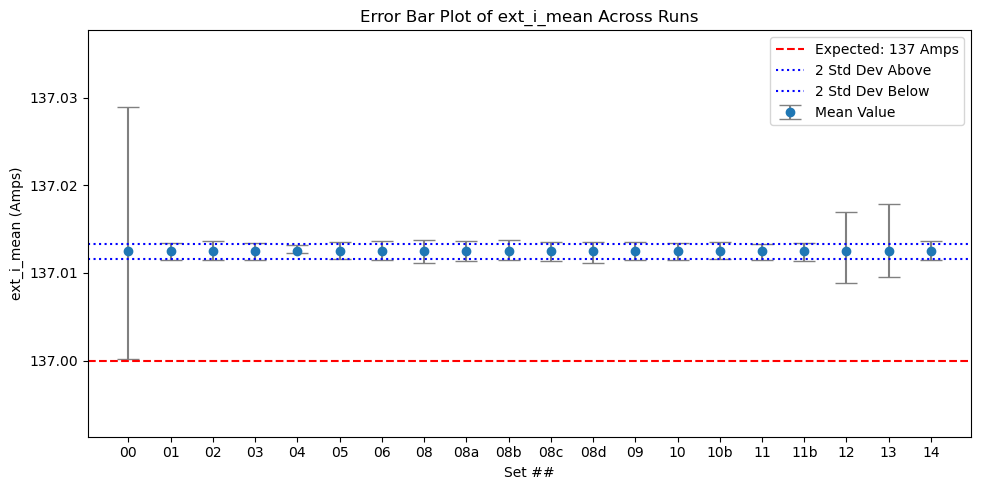

In [52]:
feature_error_plot_w_std(dataset, 'ext_i_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


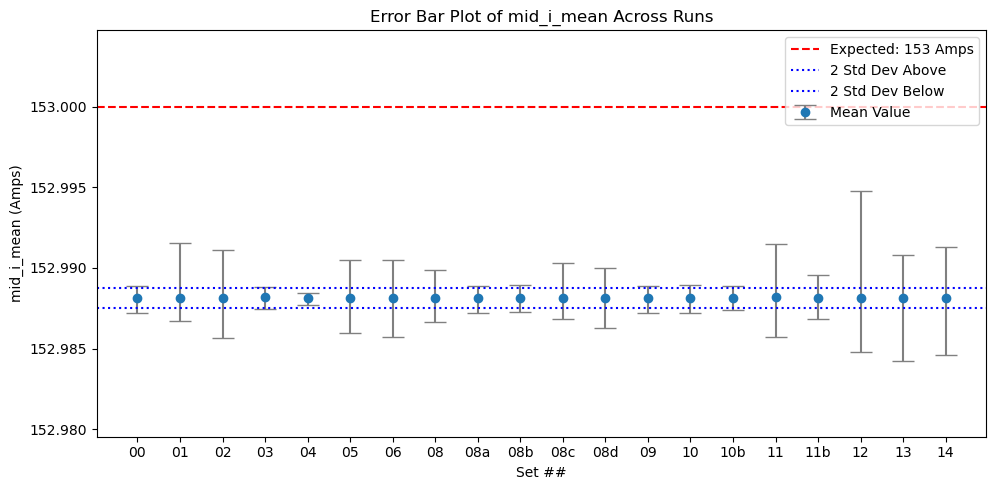

In [53]:
feature_error_plot_w_std(dataset, 'mid_i_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


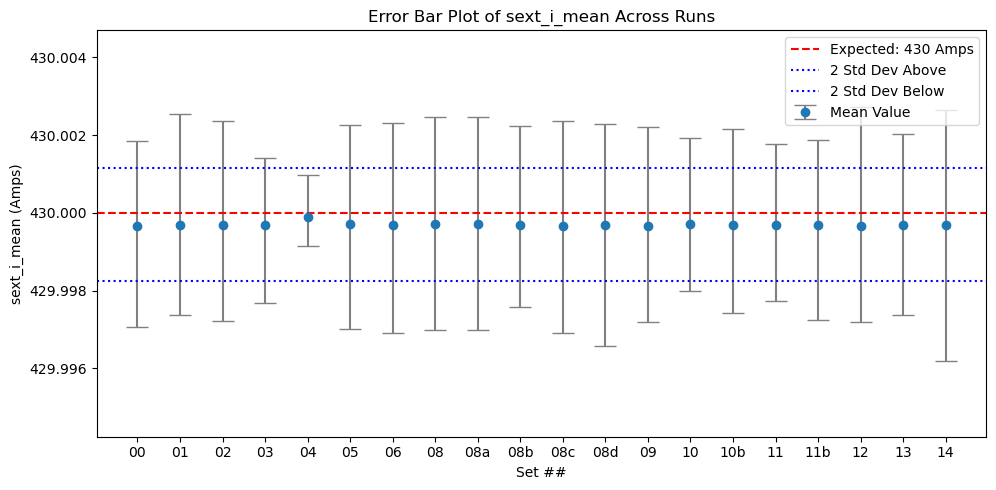

In [54]:
feature_error_plot_w_std(dataset, 'sext_i_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


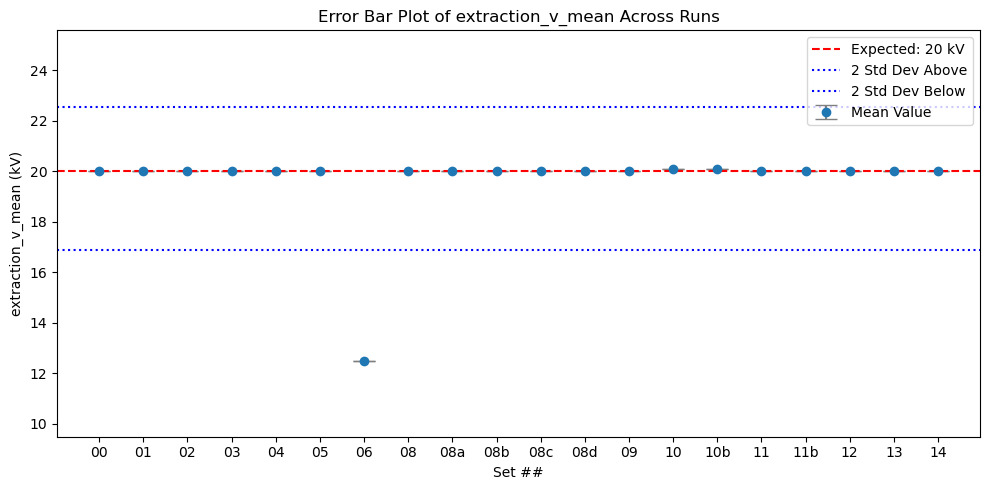

In [55]:
feature_error_plot_w_std(dataset, 'extraction_v_mean')

[<class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


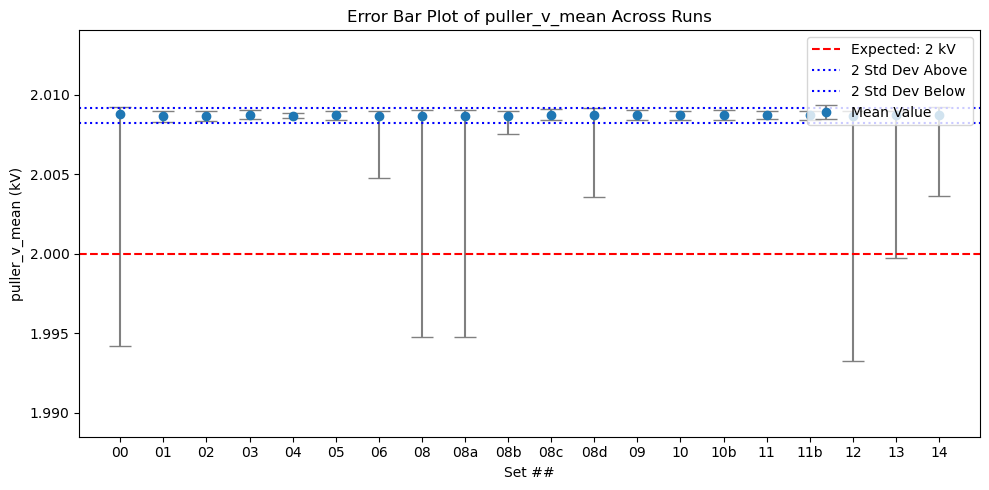

In [56]:
feature_error_plot_w_std(dataset, 'puller_v_mean')

## Examining Outlier Sets
1. Set 11 for g28_fw
2. Set 00 for ext_i
3. Set 00, 08a, 12 for puller_v

All had larger or very different ranges compared to other sets for that feature.

In [57]:
def plot_over_time(df, feature, run):
    std_dev = df[feature].std()
    overall_mean = df[feature].mean()
    one_std_above = overall_mean + 2*std_dev
    one_std_below = overall_mean - 2*std_dev
    
    df = df.loc[df['run_id'] == run, [feature, 'unix_time']]
    x_axis = df['unix_time']
    y_axis = df[feature]
    plt.figure(figsize=(5, 5))
    plt.scatter(x=x_axis, y=y_axis)
    plt.axhline(y=one_std_above, color='blue', linestyle=':', label='1 Std Dev Above')
    plt.axhline(y=one_std_below, color='blue', linestyle=':', label='1 Std Dev Below')
    plt.title(f'Scatter Plot of {feature} Over Set {run}')
    plt.xlabel('Unix Time')
    plt.ylabel(f"{feature} value")
    plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
    plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)
    plt.tight_layout()
    plt.show()

In [58]:
df = dataset.inputs

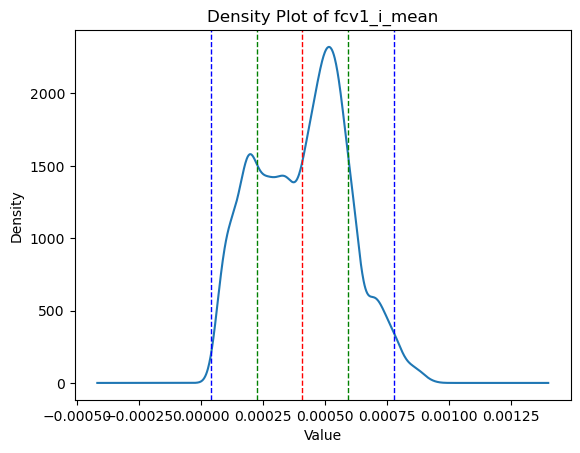

In [59]:
feature = 'fcv1_i_mean'
# df = df.loc[df['run_id'] != '06']
mean = df[feature].mean()
std_dev = df[feature].std()
df[feature].plot(kind='density')
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(mean + std_dev, color='green', linestyle='dashed', linewidth=1, label='+1 Std Dev')
plt.axvline(mean - std_dev, color='green', linestyle='dashed', linewidth=1, label='-1 Std Dev')
plt.axvline(mean + 2*std_dev, color='b', linestyle='dashed', linewidth=1, label='+2 Std Dev')
plt.axvline(mean - 2*std_dev, color='b', linestyle='dashed', linewidth=1, label='-2 Std Dev')
plt.title(f'Density Plot of {feature}')
plt.xlabel('Value')
plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)
plt.show()

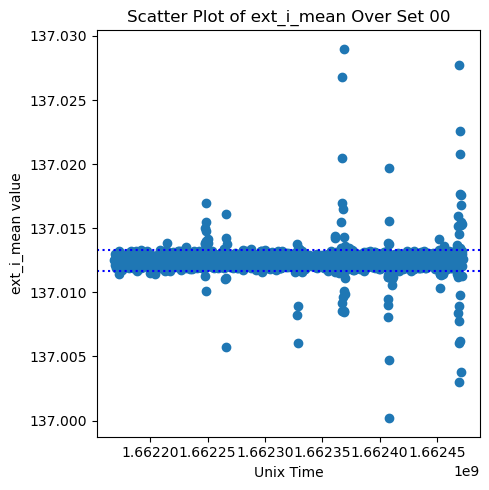

In [60]:
plot_over_time(df, "ext_i_mean", '00')

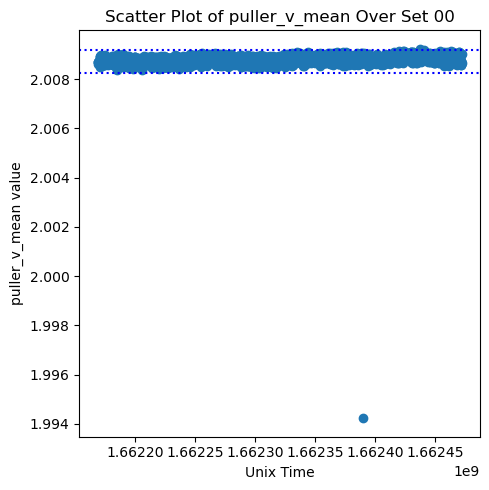

In [61]:
plot_over_time(df, "puller_v_mean", '00')

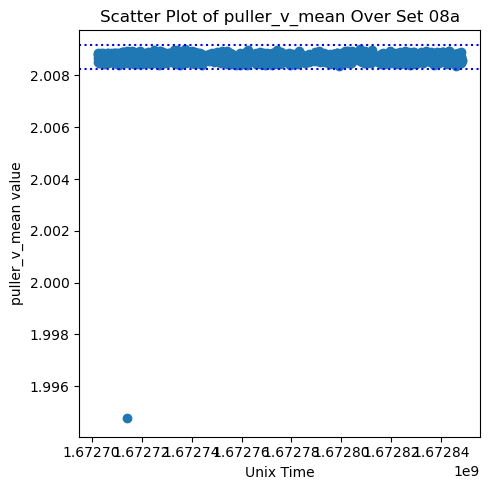

In [62]:
plot_over_time(df, "puller_v_mean", '08a')

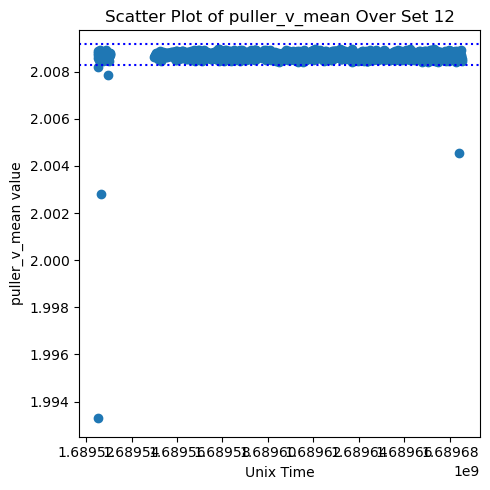

In [63]:
plot_over_time(df, "puller_v_mean", '12')